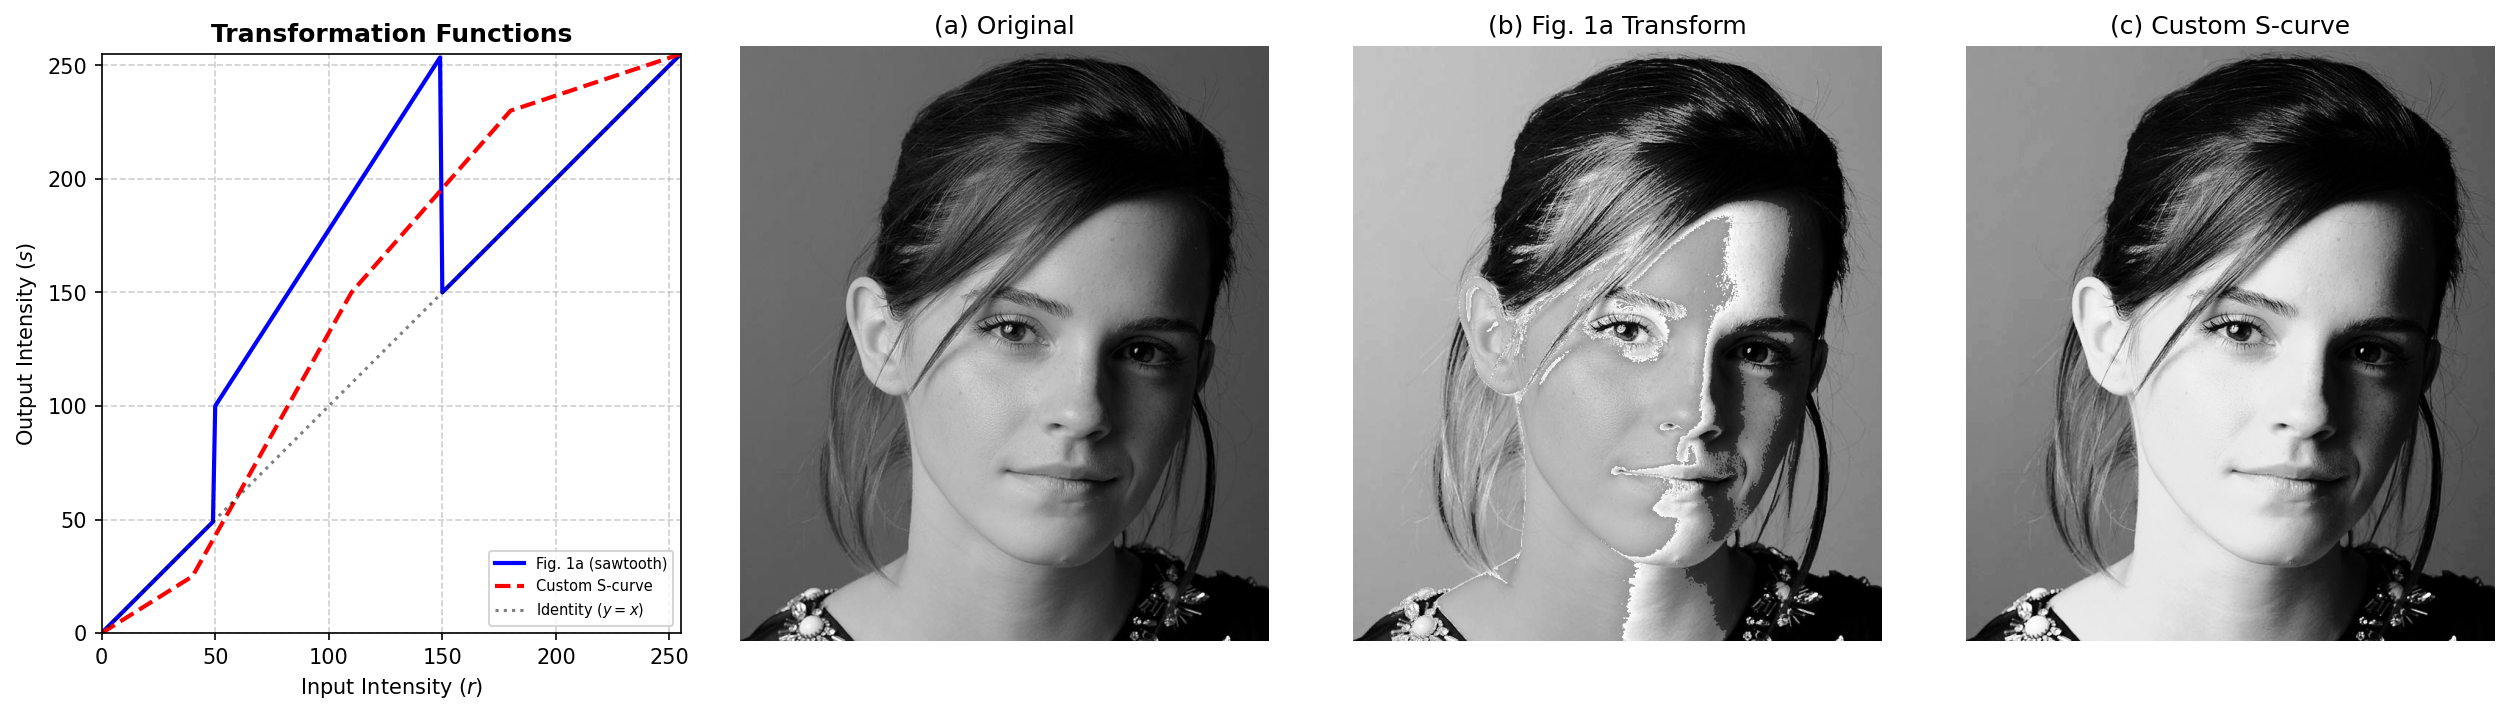

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def intensity_transform(im, breakpoints):
  
    bp = np.array(breakpoints, dtype=np.float32)
    lut = np.zeros(256, dtype=np.float32)

    for i in range(len(bp) - 1):
        x0, y0 = bp[i]
        x1, y1 = bp[i + 1]
        xs = np.arange(int(x0), int(x1) + 1)
        if x1 == x0:
            lut[xs] = y1
        else:
            lut[xs] = y0 + (y1 - y0) * (xs - x0) / (x1 - x0)

    lut = np.clip(np.round(lut), 0, 255).astype(np.uint8)
    return cv2.LUT(im, lut)


def build_lut(breakpoints):
    bp = np.array(breakpoints, dtype=np.float32)
    lut = np.zeros(256, dtype=np.float32)
    for i in range(len(bp) - 1):
        x0, y0 = bp[i]
        x1, y1 = bp[i + 1]
        xs = np.arange(int(x0), int(x1) + 1)
        if x1 == x0:
            lut[xs] = y1
        else:
            lut[xs] = y0 + (y1 - y0) * (xs - x0) / (x1 - x0)
    return lut



img_path = r'images\emma.jpeg'
im_orig = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

bp_default = [
    [0,   0],
    [50,  50],
    [50,  100],   # jump up
    [150, 255],
    [150, 150],   # jump down
    [255, 255]
]

# ---- (2) Custom smooth S-curve — no discontinuities, gentler contrast boost ----
bp_custom = [
    [0,   0],
    [40,  25],
    [110, 150],
    [180, 230],
    [255, 255]
]

im_trans_default = intensity_transform(im_orig, bp_default)
im_trans_custom  = intensity_transform(im_orig, bp_custom)

lut_def = build_lut(bp_default)
lut_cus = build_lut(bp_custom)

fig, axes = plt.subplots(1, 4, figsize=(17, 4.5), dpi=150)

r = np.arange(256)
axes[0].plot(r, lut_def, 'b-', linewidth=2, label='Fig. 1a (sawtooth)')
axes[0].plot(r, lut_cus, 'r--', linewidth=2, label='Custom S-curve')
axes[0].plot([0, 255], [0, 255], 'k:', alpha=0.5, label='Identity ($y=x$)')
axes[0].set_title('Transformation Functions', fontweight='bold')
axes[0].set_xlabel('Input Intensity ($r$)')
axes[0].set_ylabel('Output Intensity ($s$)')
axes[0].set_xlim(0, 255); axes[0].set_ylim(0, 255)
axes[0].set_aspect('equal')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend(loc='lower right', fontsize=7)

axes[1].imshow(im_orig, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('(a) Original')
axes[1].axis('off')

axes[2].imshow(im_trans_default, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('(b) Fig. 1a Transform')
axes[2].axis('off')

axes[3].imshow(im_trans_custom, cmap='gray', vmin=0, vmax=255)
axes[3].set_title('(c) Custom S-curve')
axes[3].axis('off')

plt.tight_layout()
plt.show()

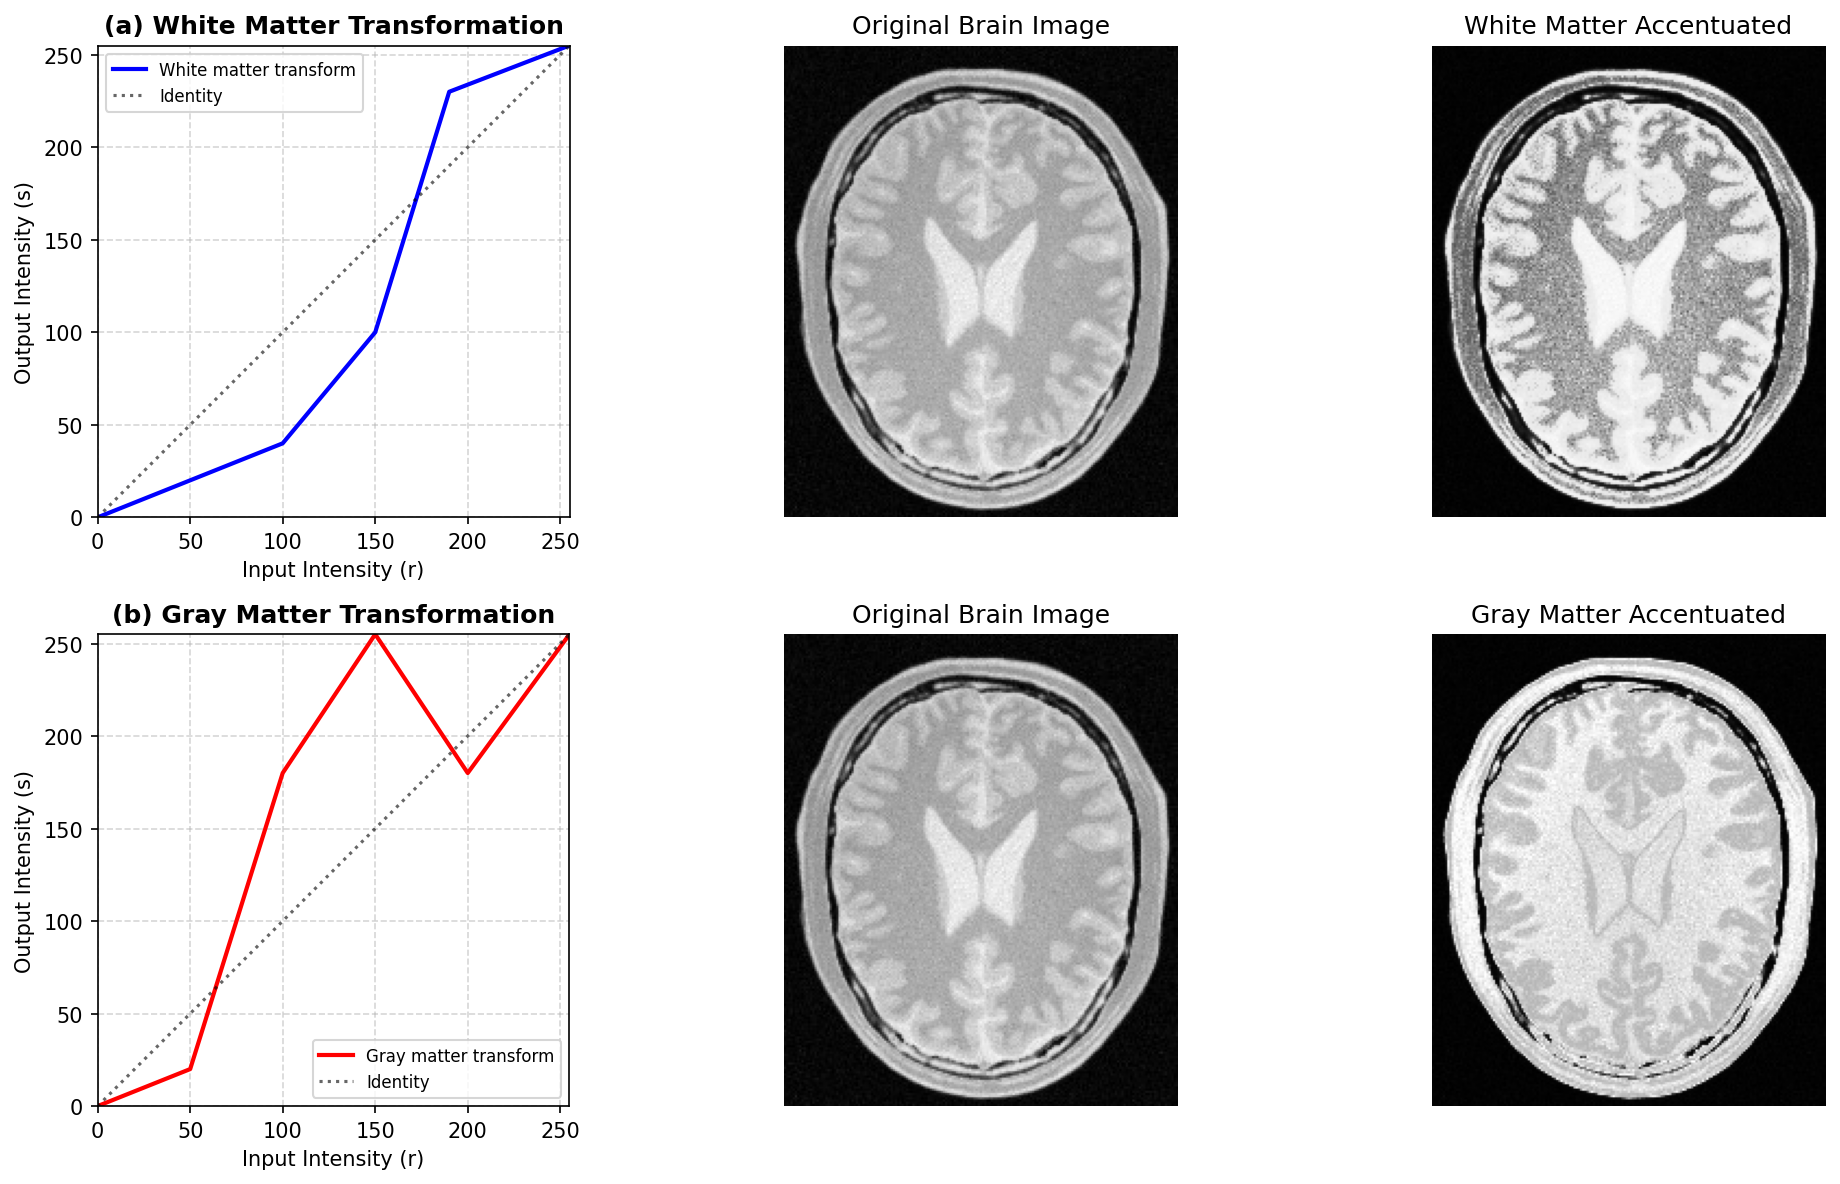

In [19]:
img_path = r'images\brain.jpeg'

im_orig = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

if im_orig is None:
    raise FileNotFoundError("Could not find the image.")

# (a) ACCENTUATE WHITE MATTER
bp_white = [
    [0,   0],
    [100, 40],
    [150, 100],
    [190, 230],
    [255, 255]
]

# (b) ACCENTUATE GRAY MATTER
bp_gray = [
    [0,   0],
    [50,  20],
    [100, 180],
    [150, 255],
    [200, 180],
    [255, 255]
]

im_white = intensity_transform(im_orig, bp_white)
im_gray = intensity_transform(im_orig, bp_gray)

lut_white = build_lut(bp_white)
lut_gray = build_lut(bp_gray)

r = np.arange(256)
fig, axes = plt.subplots(2, 3, figsize=(14, 8), dpi=150)

# WHITE MATTER
axes[0, 0].plot(
    r, lut_white,
    'b-', linewidth=2,
    label='White matter transform'
)

axes[0, 0].plot(
    [0, 255], [0, 255],
    'k:', alpha=0.6,
    label='Identity'
)

axes[0, 0].set_title(
    '(a) White Matter Transformation',
    fontweight='bold'
)

axes[0, 0].set_xlabel('Input Intensity (r)')
axes[0, 0].set_ylabel('Output Intensity (s)')
axes[0, 0].set_xlim(0, 255)
axes[0, 0].set_ylim(0, 255)
axes[0, 0].set_aspect('equal')
axes[0, 0].grid(True, linestyle='--', alpha=0.5)
axes[0, 0].legend(fontsize=8)


axes[0, 1].imshow(
    im_orig,
    cmap='gray',
    vmin=0,
    vmax=255
)

axes[0, 1].set_title('Original Brain Image')
axes[0, 1].axis('off')


axes[0, 2].imshow(
    im_white,
    cmap='gray',
    vmin=0,
    vmax=255
)

axes[0, 2].set_title('White Matter Accentuated')
axes[0, 2].axis('off')

# GRAY MATTER
axes[1, 0].plot(
    r, lut_gray,
    'r-', linewidth=2,
    label='Gray matter transform'
)

axes[1, 0].plot(
    [0, 255], [0, 255],
    'k:', alpha=0.6,
    label='Identity'
)

axes[1, 0].set_title(
    '(b) Gray Matter Transformation',
    fontweight='bold'
)

axes[1, 0].set_xlabel('Input Intensity (r)')
axes[1, 0].set_ylabel('Output Intensity (s)')
axes[1, 0].set_xlim(0, 255)
axes[1, 0].set_ylim(0, 255)
axes[1, 0].set_aspect('equal')
axes[1, 0].grid(True, linestyle='--', alpha=0.5)
axes[1, 0].legend(fontsize=8)


axes[1, 1].imshow(
    im_orig,
    cmap='gray',
    vmin=0,
    vmax=255
)

axes[1, 1].set_title('Original Brain Image')
axes[1, 1].axis('off')


axes[1, 2].imshow(
    im_gray,
    cmap='gray',
    vmin=0,
    vmax=255
)

axes[1, 2].set_title('Gray Matter Accentuated')
axes[1, 2].axis('off')


plt.tight_layout()
plt.show()

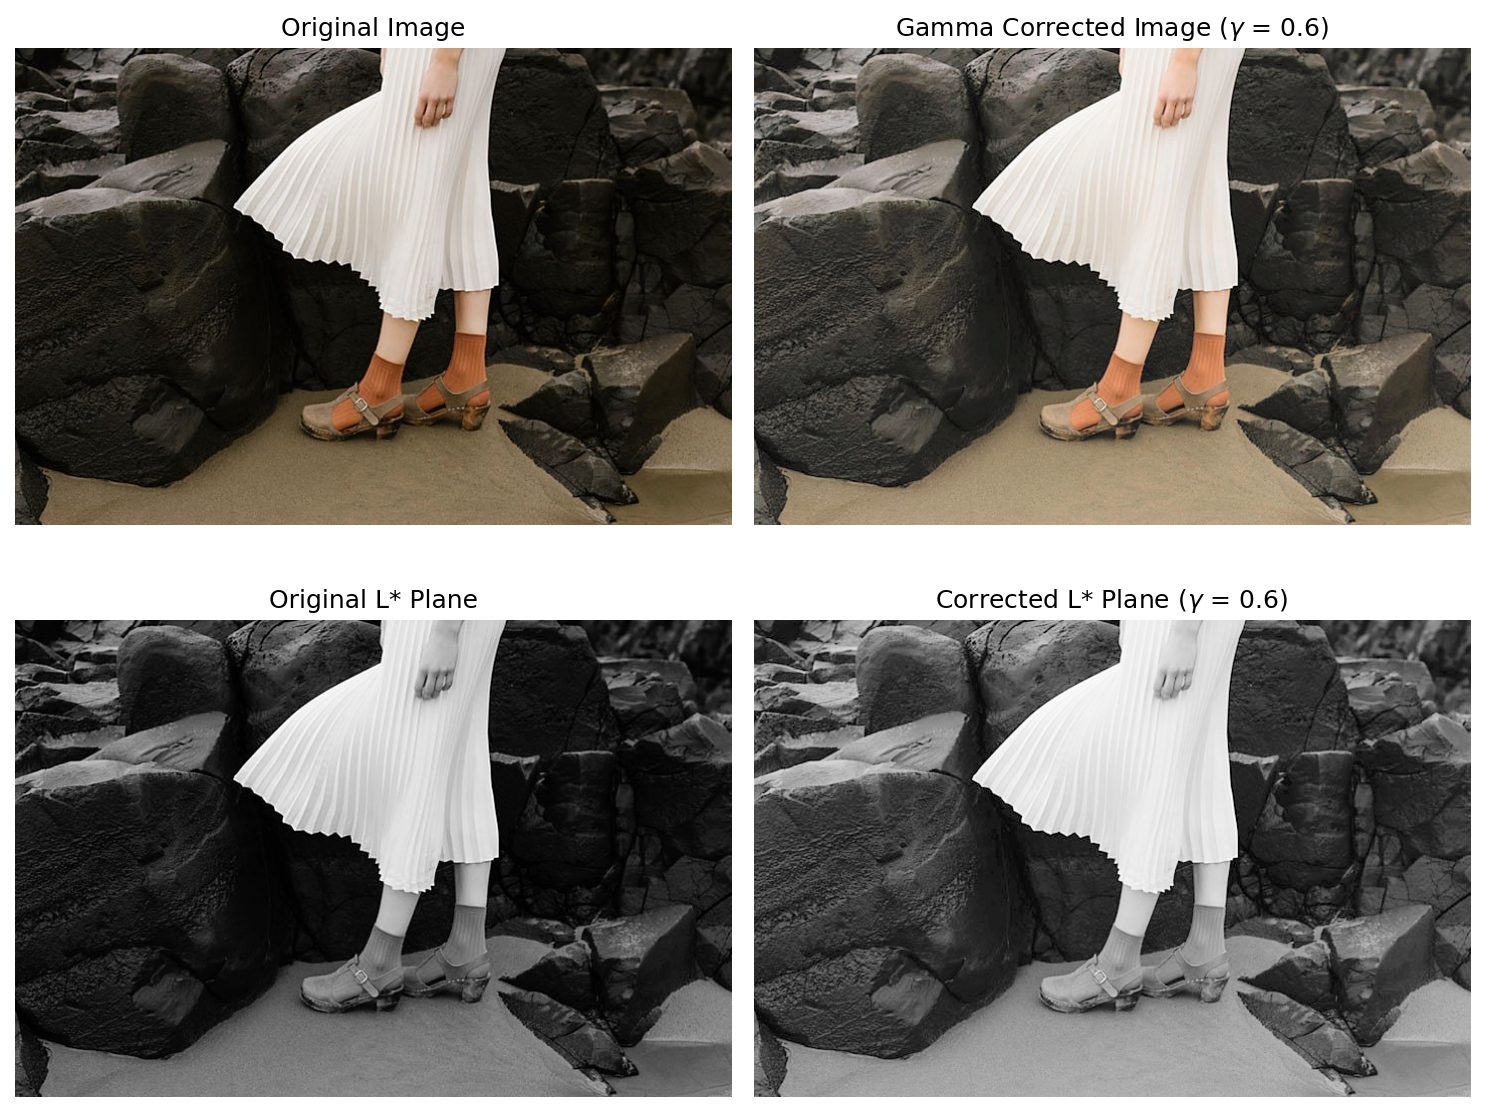

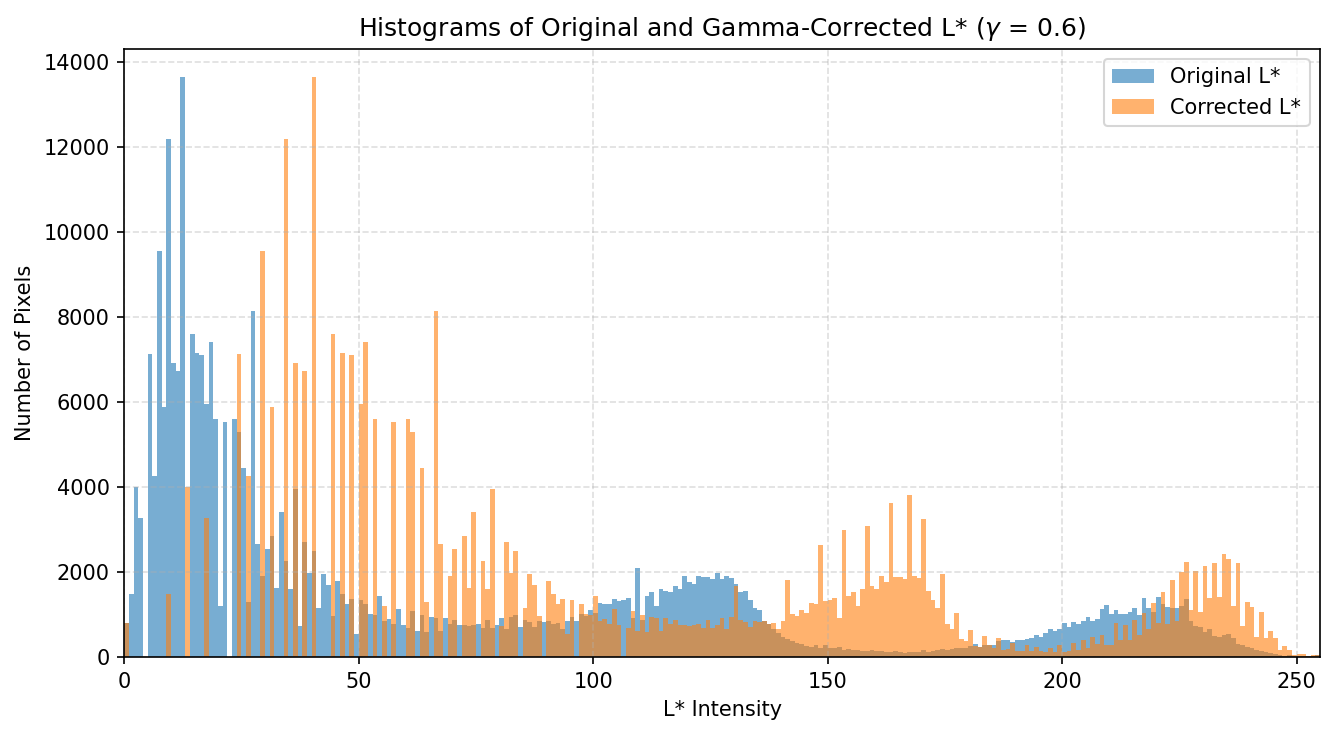

In [20]:

img_path = r'images\figure3.jpeg'
im = cv2.imread(img_path)

if im is None:
    raise FileNotFoundError("Could not find the image.")

# OpenCV reads images as BGR
im_rgb = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

# Convert RGB image to CIE L*a*b* color space
lab = cv2.cvtColor(im, cv2.COLOR_BGR2LAB)

L, a, b = cv2.split(lab)

# Gamma correction on L* plane
gamma = 0.6

# Normalize L* from [0, 255] to [0, 1]
L_norm = L.astype(np.float32) / 255.0

# Apply gamma correction
L_corrected = np.power(L_norm, gamma)

# Convert back to [0, 255]
L_corrected = np.clip(
    L_corrected * 255,
    0,
    255
).astype(np.uint8)

# Reconstruct Lab image
lab_corrected = cv2.merge([
    L_corrected,
    a,
    b
])

# Convert corrected Lab image back to RGB
im_corrected = cv2.cvtColor(
    lab_corrected,
    cv2.COLOR_LAB2RGB
)

# Display original and corrected images
fig, axes = plt.subplots(
    2, 2,
    figsize=(10, 8),
    dpi=150
)
axes[0, 0].imshow(im_rgb)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

axes[0, 1].imshow(im_corrected)
axes[0, 1].set_title(
    f'Gamma Corrected Image ($\\gamma$ = {gamma})'
)
axes[0, 1].axis('off')

axes[1, 0].imshow(
    L,
    cmap='gray',
    vmin=0,
    vmax=255
)
axes[1, 0].set_title('Original L* Plane')
axes[1, 0].axis('off')


axes[1, 1].imshow(
    L_corrected,
    cmap='gray',
    vmin=0,
    vmax=255
)
axes[1, 1].set_title(
    f'Corrected L* Plane ($\\gamma$ = {gamma})'
)
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

# Histograms of original and corrected L* planes
plt.figure(figsize=(9, 5), dpi=150)

plt.hist(
    L.ravel(),
    bins=256,
    range=(0, 256),
    alpha=0.6,
    label='Original L*'
)

plt.hist(
    L_corrected.ravel(),
    bins=256,
    range=(0, 256),
    alpha=0.6,
    label='Corrected L*'
)

plt.title(
    f'Histograms of Original and Gamma-Corrected L* ($\\gamma$ = {gamma})'
)

plt.xlabel('L* Intensity')
plt.ylabel('Number of Pixels')

plt.xlim(0, 255)
plt.legend()
plt.grid(
    True,
    linestyle='--',
    alpha=0.4
)

plt.tight_layout()
plt.show()

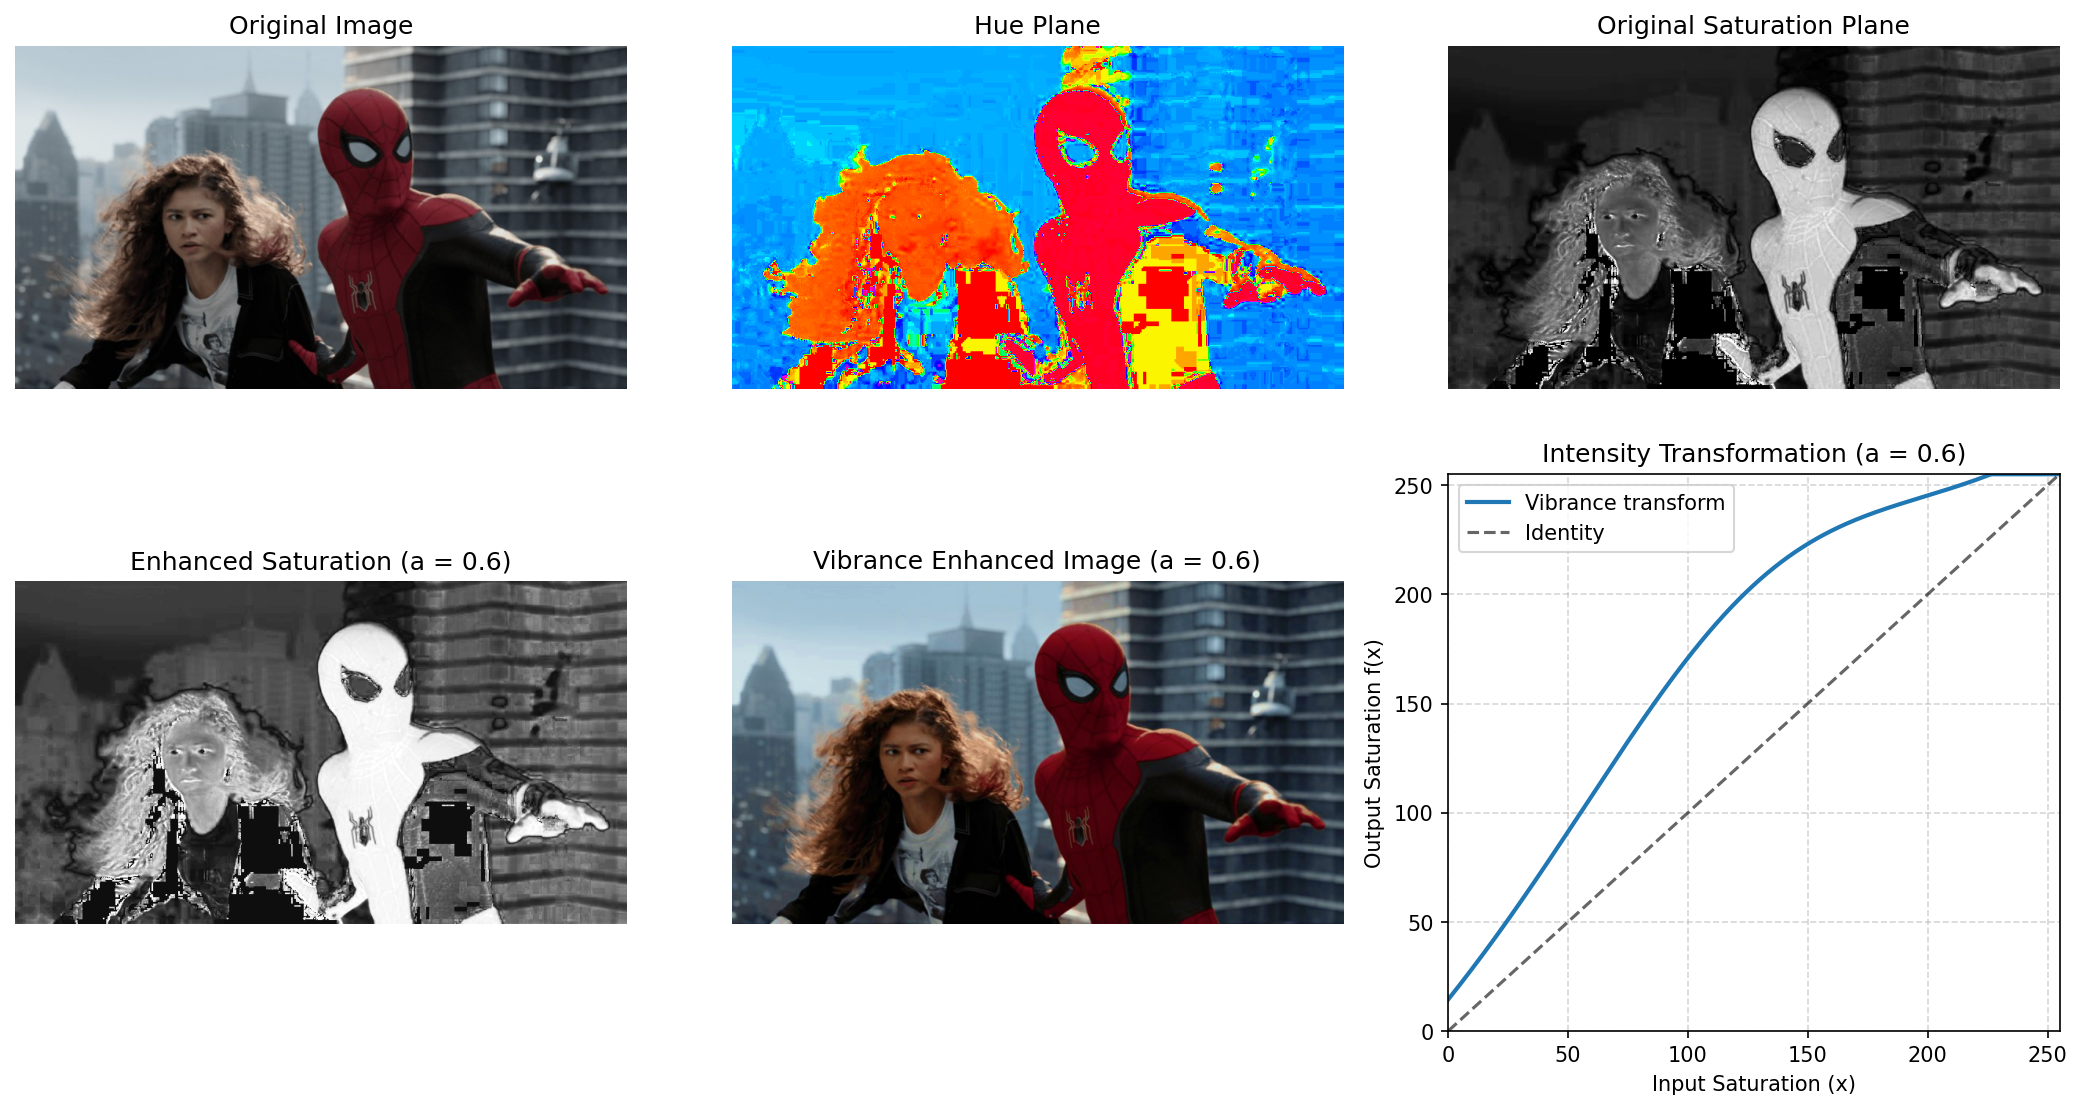

In [21]:
img_path = r'images\figure4.jpeg'
im = cv2.imread(img_path)

if im is None:
    raise FileNotFoundError("Could not find the image.")

# Convert BGR to RGB for displaying
im_rgb = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)

# Convert image to HSV
hsv = cv2.cvtColor(im, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv)

#Vibrance intensity transformation
# f(x) = min(x + a*128*exp(-(x-128)^2/(2*sigma^2)),  255)

a = 0.6
sigma = 70

x = np.arange(256, dtype=np.float32)

transformation = (
    x
    + a * 128
    * np.exp(
        -((x - 128) ** 2)
        / (2 * sigma ** 2)
    )
)

transformation = np.minimum(
    transformation,
    255
)


# Apply transformation to saturation plane
S_enhanced = transformation[S]

S_enhanced = np.clip(
    S_enhanced,
    0,
    255
).astype(np.uint8)

# Recombine H, enhanced S, and V
hsv_enhanced = cv2.merge([
    H,
    S_enhanced,
    V
])

# Convert HSV back to BGR
im_enhanced_bgr = cv2.cvtColor(
    hsv_enhanced,
    cv2.COLOR_HSV2BGR
)

# Convert BGR to RGB for matplotlib
im_enhanced = cv2.cvtColor(
    im_enhanced_bgr,
    cv2.COLOR_BGR2RGB
)

# Display results
fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 8),
    dpi=150
)
# Original image
axes[0, 0].imshow(im_rgb)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# Hue plane
axes[0, 1].imshow(
    H,
    cmap='hsv',
    vmin=0,
    vmax=179
)
axes[0, 1].set_title('Hue Plane')
axes[0, 1].axis('off')

# Saturation plane
axes[0, 2].imshow(
    S,
    cmap='gray',
    vmin=0,
    vmax=255
)
axes[0, 2].set_title('Original Saturation Plane')
axes[0, 2].axis('off')
# Enhanced saturation
axes[1, 0].imshow(
    S_enhanced,
    cmap='gray',
    vmin=0,
    vmax=255
)
axes[1, 0].set_title(
    f'Enhanced Saturation (a = {a})'
)
axes[1, 0].axis('off')
# Vibrance-enhanced image
axes[1, 1].imshow(im_enhanced)
axes[1, 1].set_title(
    f'Vibrance Enhanced Image (a = {a})'
)

axes[1, 1].axis('off')
# Intensity transformation
axes[1, 2].plot(
    x,
    transformation,
    linewidth=2,
    label='Vibrance transform'
)

axes[1, 2].plot(
    [0, 255],
    [0, 255],
    'k--',
    alpha=0.6,
    label='Identity'
)

axes[1, 2].set_title(
    f'Intensity Transformation (a = {a})'
)

axes[1, 2].set_xlabel('Input Saturation (x)')
axes[1, 2].set_ylabel('Output Saturation f(x)')

axes[1, 2].set_xlim(0, 255)
axes[1, 2].set_ylim(0, 255)

axes[1, 2].grid(
    True,
    linestyle='--',
    alpha=0.5
)

axes[1, 2].legend()


plt.tight_layout()
plt.show()

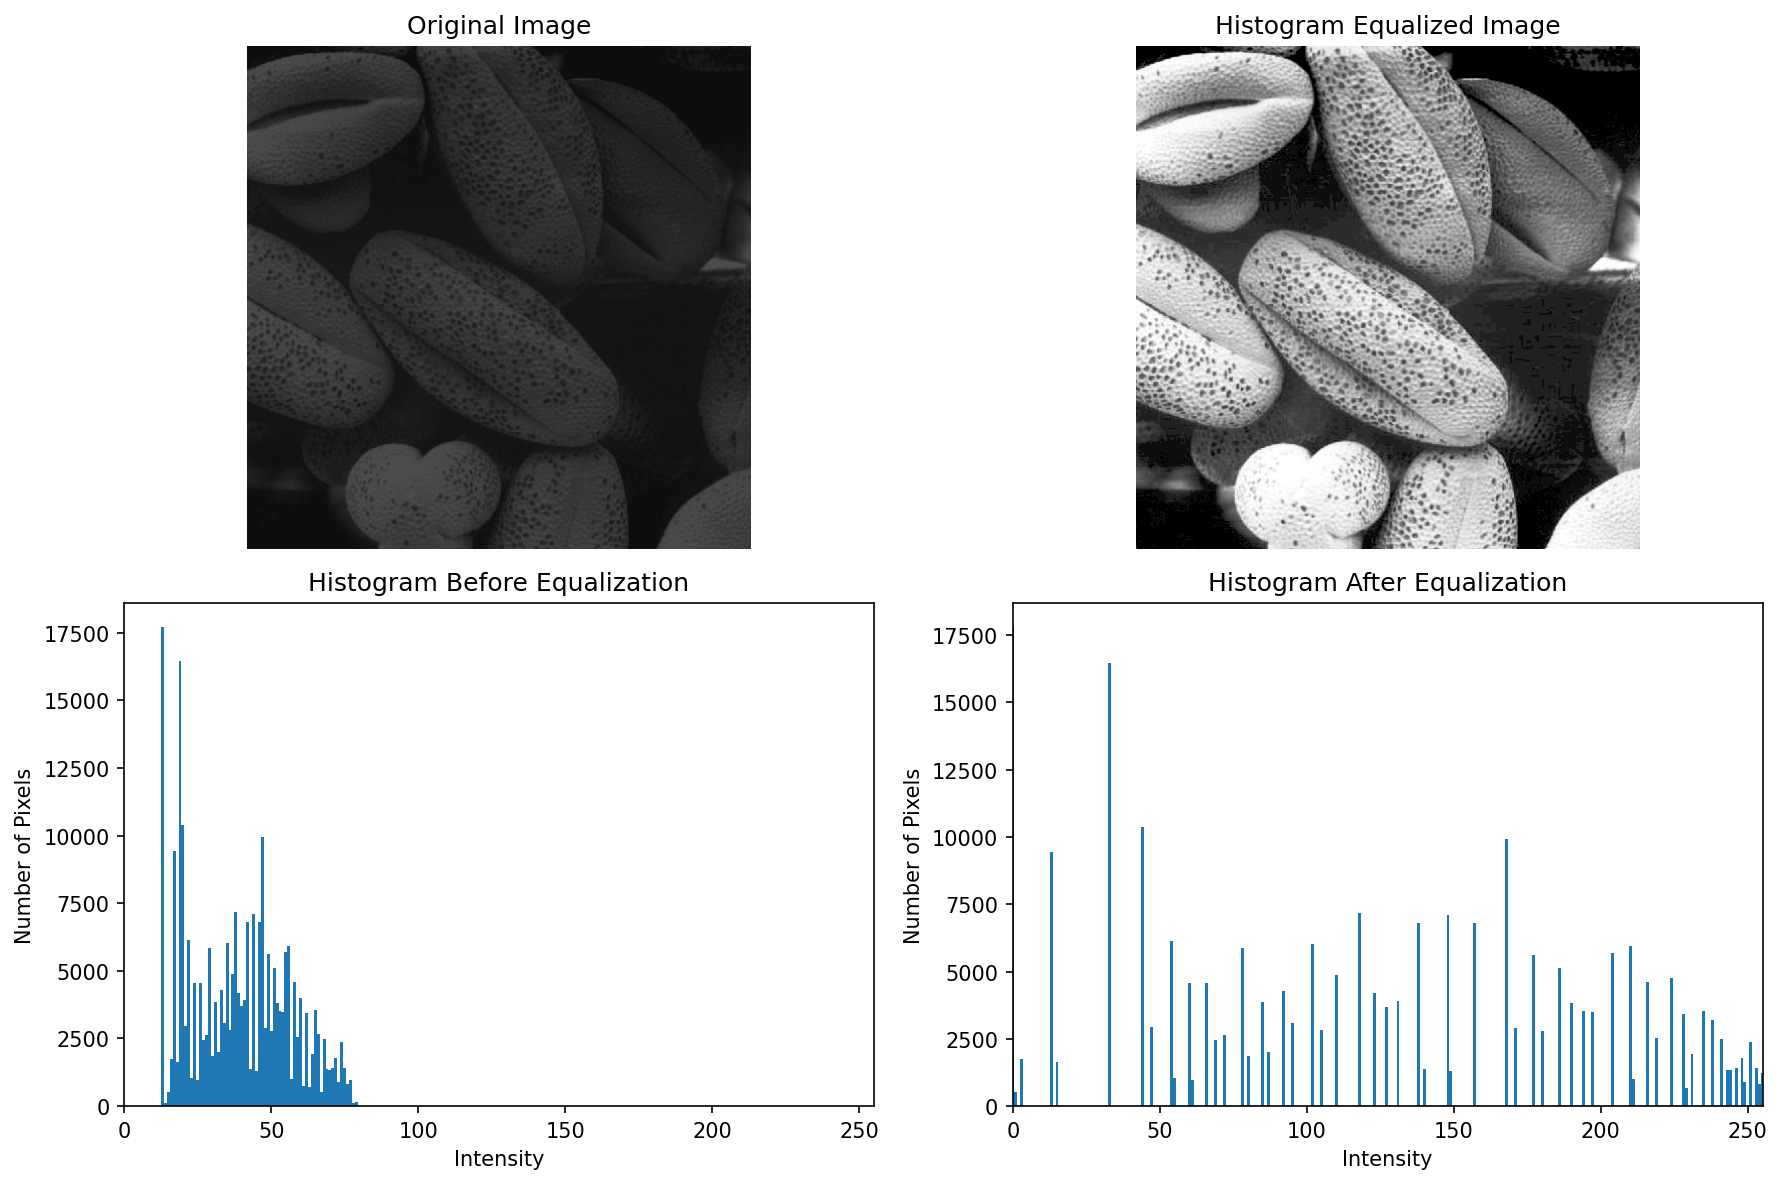

In [22]:
# Histogram Equalization function
def histogram_equalization(im):

    # Calculate histogram
    hist = np.bincount(im.ravel(),minlength=256)

    # Calculate cumulative distribution function (CDF)
    cdf = np.cumsum(hist)

    # Find first non-zero CDF value
    cdf_min = cdf[cdf > 0][0]

    # Number of pixels
    total_pixels = im.size

    # Calculate histogram equalization transformation
    lut = ((cdf - cdf_min) / (total_pixels - cdf_min) * 255)

    # Handle possible division issues
    lut = np.clip(lut, 0, 255)

    # Convert LUT to uint8
    lut = np.round(lut).astype(np.uint8)

    # Apply transformation
    equalized = lut[im]

    return equalized, hist, lut

# Read image
img_path = r'images\shells.tif'

im = cv2.imread(img_path,cv2.IMREAD_GRAYSCALE)

if im is None:
    raise FileNotFoundError("Could not find the image.")

# Apply our histogram equalization
im_equalized, hist_before, lut = histogram_equalization(im)

# Calculate histogram after equalization
hist_after = np.bincount(im_equalized.ravel(),minlength=256)

# Display results
fig, axes = plt.subplots(
    2, 2,
    figsize=(12, 8),
    dpi=150
)
# Original image
axes[0, 0].imshow(
    im,
    cmap='gray',
    vmin=0,
    vmax=255
)
axes[0, 0].set_title('Original Image')
axes[0, 0].axis('off')

# Equalized image
axes[0, 1].imshow(
    im_equalized,
    cmap='gray',
    vmin=0,
    vmax=255
)
axes[0, 1].set_title('Histogram Equalized Image')
axes[0, 1].axis('off')

# Histogram before
axes[1, 0].bar(
    np.arange(256),
    hist_before,
    width=1
)
axes[1, 0].set_title(
    'Histogram Before Equalization'
)
axes[1, 0].set_xlabel('Intensity')
axes[1, 0].set_ylabel('Number of Pixels')
axes[1, 0].set_xlim(0, 255)

# Histogram after
axes[1, 1].bar(
    np.arange(256),
    hist_after,
    width=1
)
axes[1, 1].set_title(
    'Histogram After Equalization'
)
axes[1, 1].set_xlabel('Intensity')
axes[1, 1].set_ylabel('Number of Pixels')
axes[1, 1].set_xlim(0, 255)
plt.tight_layout()
plt.show()